In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/credit_risk_dataset.csv.zip")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [8]:
df['loan_status'].unique()

array([1, 0])

In [9]:
#Its a classification problem so there are high chances of class imbalance.
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

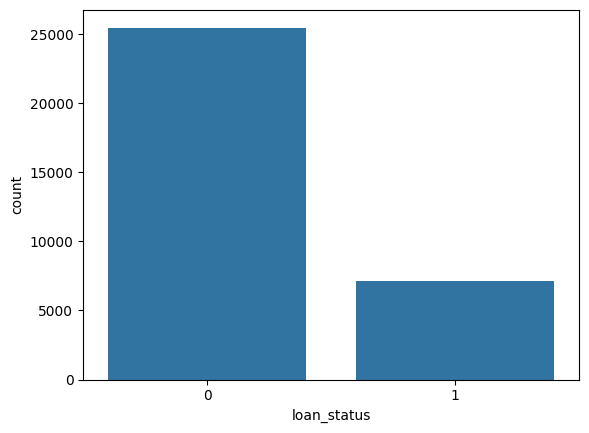

In [10]:
sns.countplot(x='loan_status',data=df)

In [11]:
#Outlier check
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

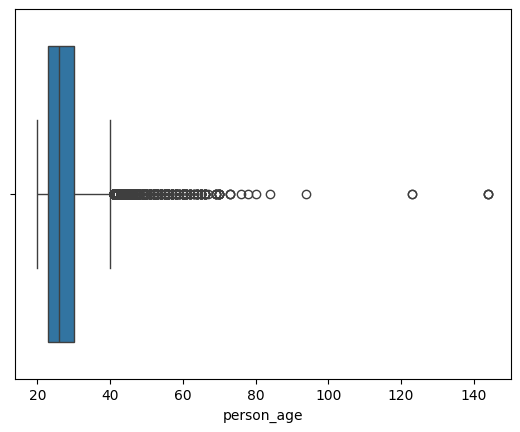

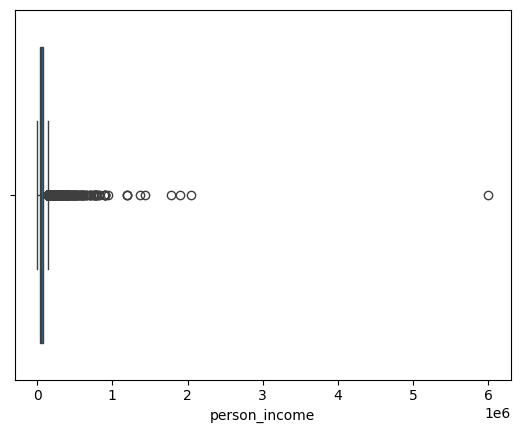

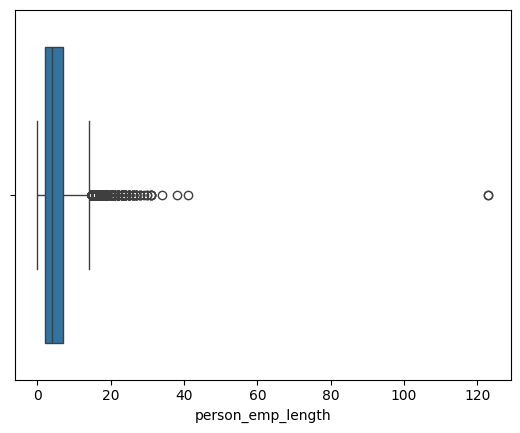

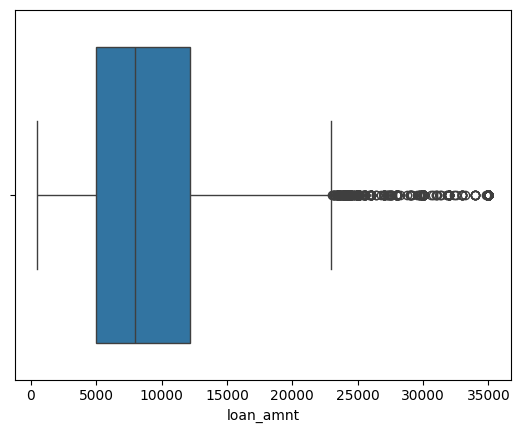

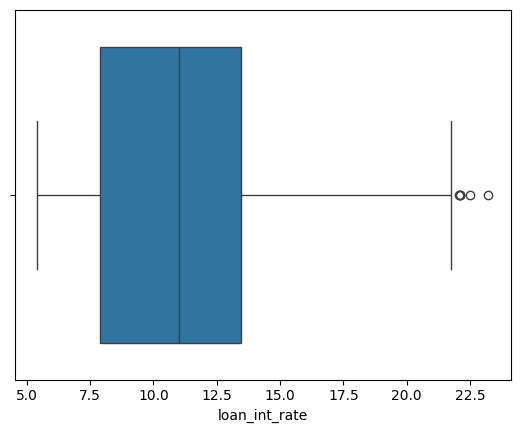

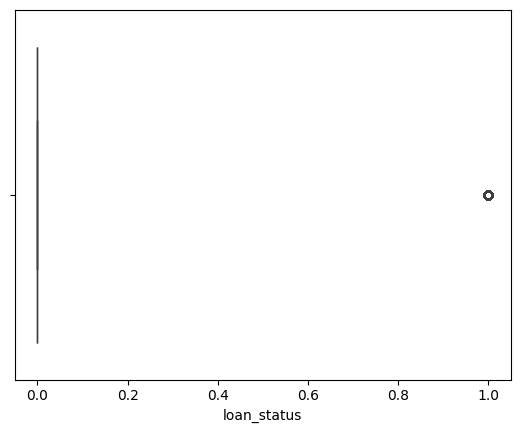

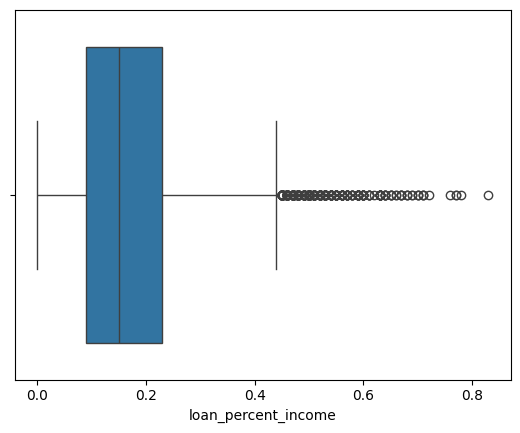

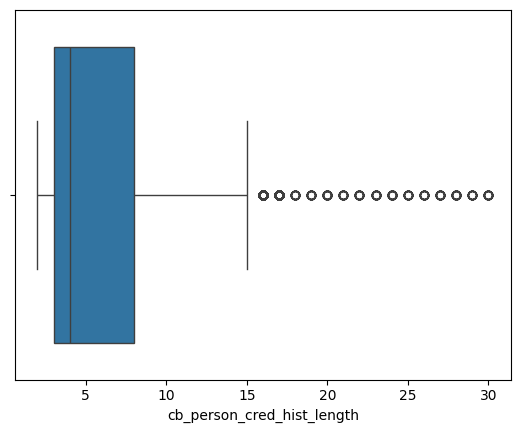

In [12]:
for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [13]:
(df['person_age']>100).sum()

np.int64(5)

In [14]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

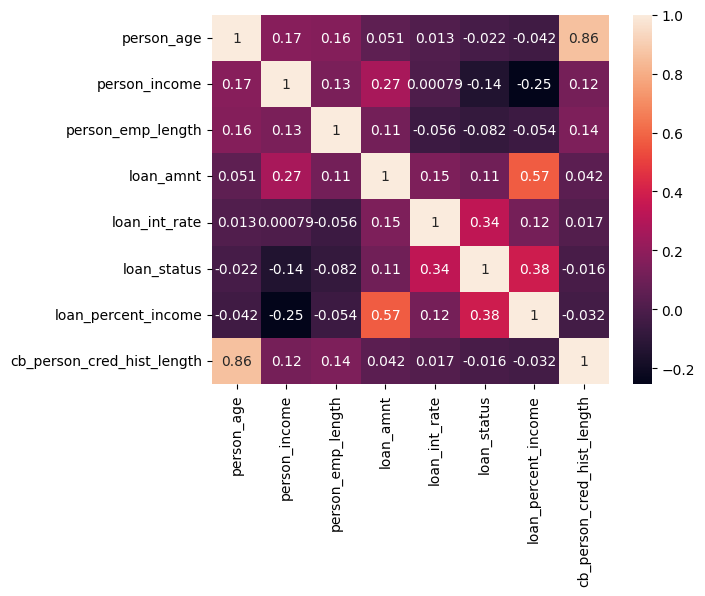

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [16]:
df_copy = df.copy()
print(f"Original Rows : {df_copy.shape[0]}")

#Remove Duplicate Rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or above 100
#Remove employment length greater than age or extreme outliers (>60)

df_copy = df_copy[(df_copy['person_age']>=18) & (df_copy['person_age']<=100)]
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]
df_copy.head()

Original Rows : 32581
Rows after removing duplicates : 32416


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [17]:
X = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
#Standard Scaler on Numerical columns
#One Hot Encoding on categorical columns
numeric_cols = ['person_age','person_income','person_emp_length','loan_amnt',
       'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

categorical_cols = df.select_dtypes(include=object).columns.tolist()
categorical_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [20]:
#Handling class imbalance
#Using Class-Weights
neg, pos = np.bincount(y_train)
scale_weights = neg/pos
scale_weights

np.float64(3.6312213039485766)

In [21]:
#Pipeline and Column Transfer
#Preprocessing for Logistic Regression : Impute + SCALE Numeric feature + One Hot Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline for numerical columns
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]), numeric_cols),

        #Pipeline for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [22]:
#Pipeline and Column Transfer
#Preprocessing for XGBoost : Impute numeric only (No Scaling), impute + One-Hot Encoding

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline for numerical columns
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score,f1_score,confusion_matrix, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)
  #Metrics
  accuracy = accuracy_score(y_test,y_pred)
  precision_s = precision_score(y_test,y_pred)
  recall_s = recall_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)

  #Confusion Matrix
  cm = confusion_matrix(y_test,y_pred)
  class_report = classification_report(y_test,y_pred)

  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision_s:.2f}")
  print(f"Recall : {recall_s:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)

  sns.heatmap(cm,annot=True,fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()

  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test,y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precsion-Recall Curve")
  plt.show()

In [24]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [25]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))
])
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [26]:
#XGBoost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights,random_state=42,n_jobs=-1
    ))
])

In [27]:
for cv_name,pipe in [("Logistic Regression", lr_cv_pipeline),
                         ("XGBoost", xgb_cv_pipeline)]:

                         cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

                         print(cv_name)
                         print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                         print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                         print(f"Precision : {cv_results['test_precision'].mean()}")
                         print(f"Recall : {cv_results['test_recall'].mean()}")
                         print(f"F1 : {cv_results['test_f1'].mean()}")

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108
XGBoost
ROC-AUC : 0.9393848243386111
Accuracy : 0.9086724038455642
Precision : 0.7913354492271174
Recall : 0.7856749311294765
F1 : 0.7880291923045915


In [28]:
cv_results

{'fit_time': array([0.67914081, 0.66086936, 1.02802515, 0.86809444, 1.49952221]),
 'score_time': array([0.1072073 , 0.11106801, 0.23226213, 0.19161534, 0.32724309]),
 'test_roc_auc': array([0.94306506, 0.93043619, 0.94080108, 0.94479977, 0.93782203]),
 'test_accuracy': array([0.9129659 , 0.91237113, 0.90838786, 0.9109657 , 0.89867143]),
 'test_precision': array([0.80545113, 0.82317682, 0.79000925, 0.78933092, 0.74870912]),
 'test_recall': array([0.78696051, 0.75665748, 0.78420569, 0.80165289, 0.79889807]),
 'test_f1': array([0.79609847, 0.78851675, 0.78709677, 0.79544419, 0.77298978])}

In [29]:
#Baseline Model
baseline_model = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [30]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_weights,random_state=42))
])
xg_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



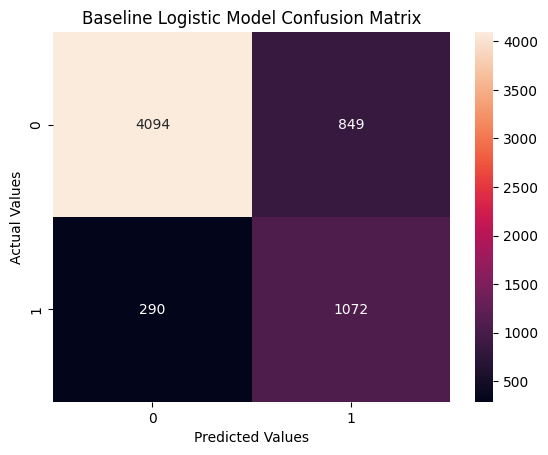

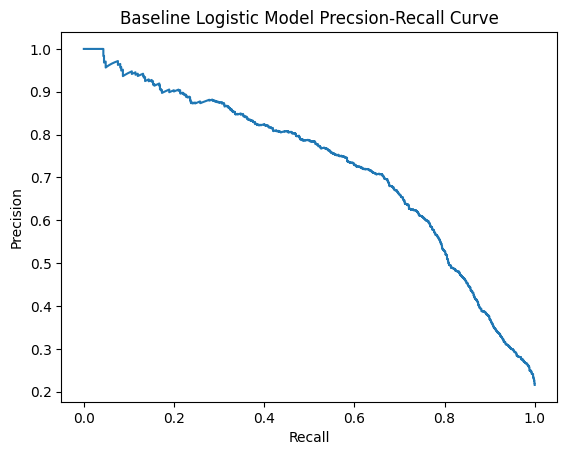

In [31]:
evaluate_model("Baseline Logistic Model", baseline_model,X_test,y_test)

Accuracy : 0.92
Precision : 0.82
Recall : 0.79
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



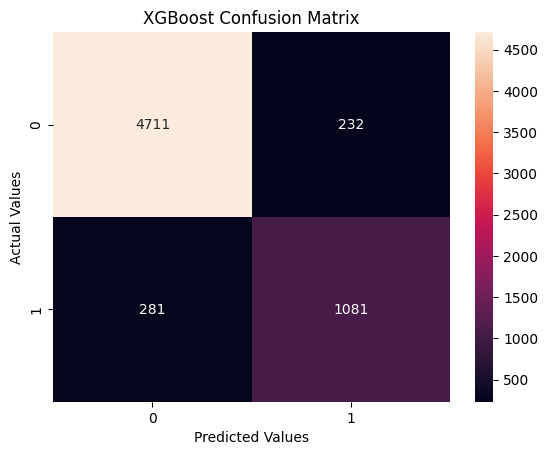

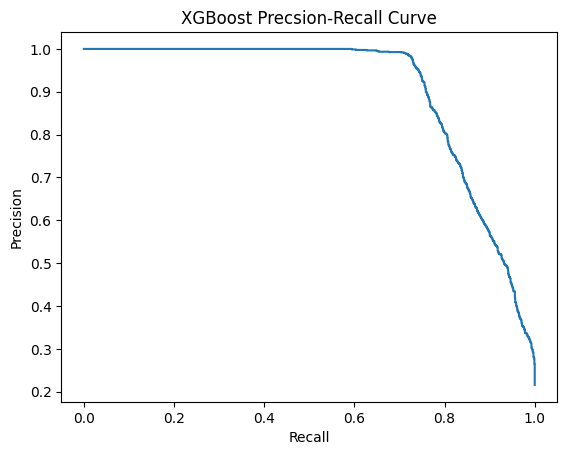

In [32]:
evaluate_model("XGBoost", xg_model, X_test, y_test)

In [33]:
#Hyperparameter Tuning for XGBoost

In [34]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform
param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01,0.5),
    "classifier__subsample": uniform(0.6,0.4),#Rows Sampling
    "classifier__colsample_bytree": uniform(0.6,0.4),#Column Sampling
    "classifier__min_child_weight": randint(1,10),
    "classifier__gamma": uniform(0,5)
}

In [35]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a20ad4d4e10>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a20ad6dfe00>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a20ad4d4a50>},
                   scoring='average_precision', verbose=1)

In [36]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.6156720473560465),
 'classifier__gamma': np.float64(0.9380518015424782),
 'classifier__learning_rate': np.float64(0.12303207349067401),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 505,
 'classifier__subsample': np.float64(0.9067176817390539)}

In [37]:
print(f"Score after performing tunning {random_search.best_score_:.2f}")

Score after performing tunning 0.90


Accuracy : 0.92
Precision : 0.82
Recall : 0.81
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



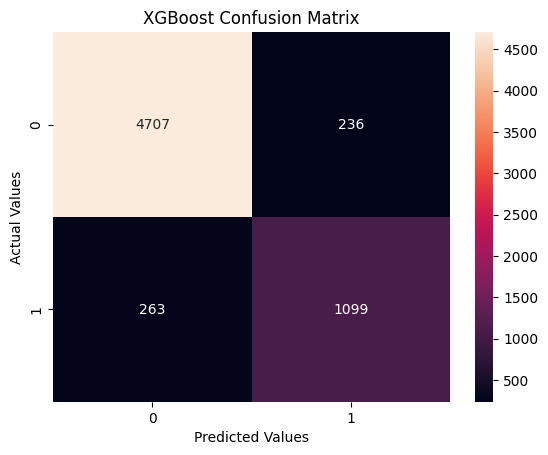

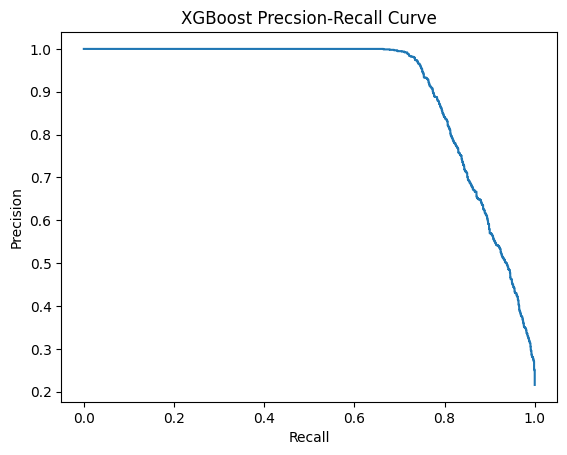

In [38]:
#Passing the XGBoost model after performing Hyper Parameter Tuning ->
evaluate_model("XGBoost",random_search,X_test,y_test)

Accuracy : 0.92
Precision : 0.82
Recall : 0.81
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



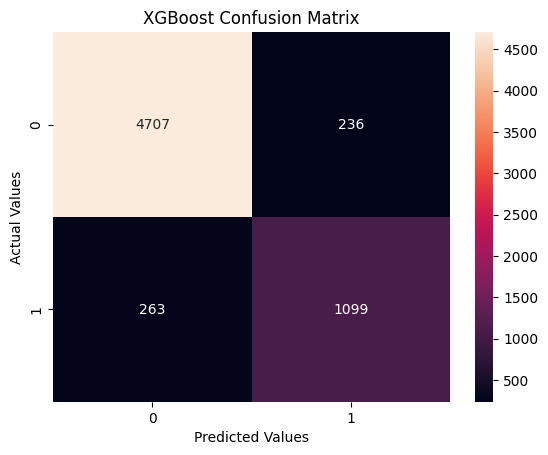

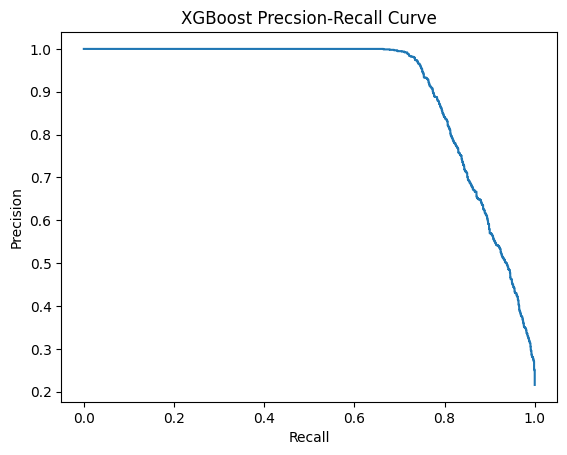

In [39]:
#Passing the XGBoost model after performing Hyper Parameter Tuning ->
evaluate_model("XGBoost",random_search.best_estimator_,X_test,y_test)

In [40]:
#Probability Calibration
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/Sigmoid -> Adjust the probabilities using a sigmoid curve.
2.Isotonic Regression -> Learn a flexible mapping from old prob. - better probability.
3.Temperature Scaling -> Adjust the confidence of neural network predictions using one temperature.
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/Sigmoid -> Adjust the probabilities using a sigmoid curve.\n2.Isotonic Regression -> Learn a flexible mapping from old prob. - better probability.\n3.Temperature Scaling -> Adjust the confidence of neural network predictions using one temperature.\n'

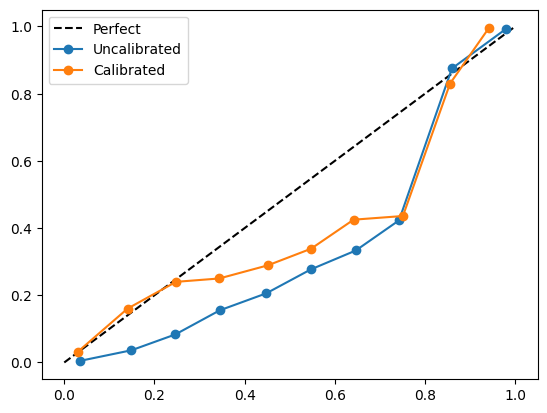

In [41]:
#1. Calibrate the XGBoost Model :
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    cv=5,
    method="sigmoid"
)
calibrated_model.fit(X_train,y_train)

#2. Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:,1]
uncalibrated
calibrated = calibrated_model.predict_proba(X_test)[:,1]

#3. Create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

#4. Plot
plt.plot([0,1], [0,1], 'k--', label="Perfect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [42]:
#SHAP Interpretation - Global And Local
!pip install shap
import shap

In [43]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']
xgb_classifier
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

#4. Get features names after one hot encoding,so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

#5.Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed,columns=feature_names)

#6.Create SHAP explainer built for tree based model.
explainer = shap.TreeExplainer(xgb_classifier)

#7.Calculate the SHAP values for every row in the test set.
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

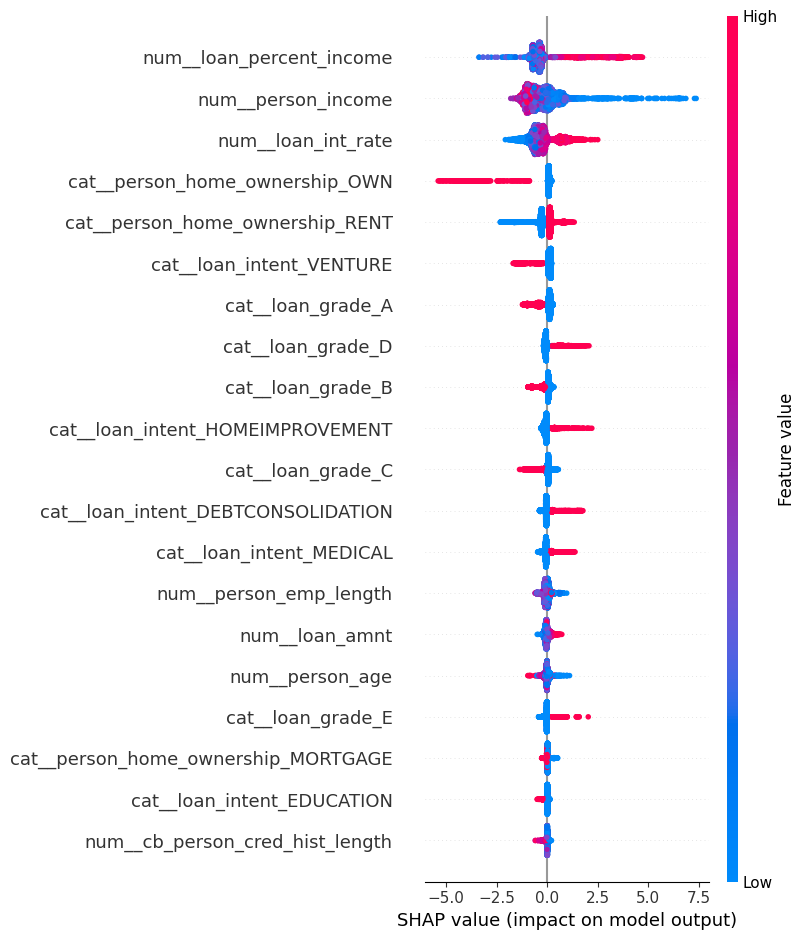

In [44]:
#Global Explaination -->
shap.summary_plot(shap_values, X_test_df)


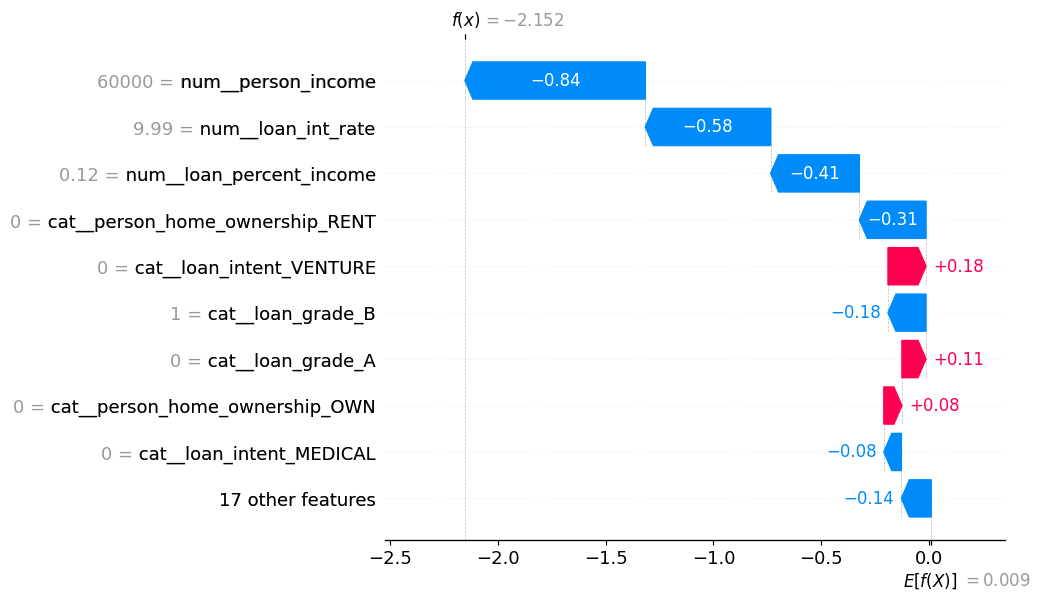

In [49]:
row_index = 5

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

In [52]:
#Analyzing False Positives and False Negatives
#Get predictions from the best performing XGBoost model on the test set.
y_pred = random_search.predict(X_test)

#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred


In [53]:
#Identify False Positive : Model predicted 1,but the actual was 0.
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

#Identify False Negative : Model predicted 0,but the actual was 1.
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

In [54]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 236
False Negative : 263


In [55]:
#Save the final model.
import joblib
joblib.dump(calibrated_model,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [56]:
from sklearn.metrics import precision_recall_curve
import numpy as np

calibrated_proba = calibrated_model.predict_proba(X_test)[:,1]

precisions,recalls,thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2*(precisions*recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"New Threshold : {best_threshold}")

New Threshold : 0.6275556406426313


In [57]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']